05_shap_analysis.ipynb
+ SHAP
+ açıklanabilirlik
+ risk faktörleri

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(project_root)

c:\Users\ASUS\creditguard-ai


In [2]:
import numpy as np
import pyarrow

print(np.__version__)
print(pyarrow.__version__)

1.26.4
16.1.0


In [2]:
from src.preprocessing.prepare_dataset import (
    prepare_dataset
)

df = prepare_dataset(
    "../data/processed/train_feature_store.parquet"
)

X = df.drop(
    columns=["TARGET"]
)

print(X.shape)

(307511, 183)


In [3]:
import joblib
import shap

model = joblib.load(
    #"../artifacts/models/lgbm_tuned.pkl"
    "../artifacts/models/lgbm_optuna_cv.pkl"
)

model

,num_leaves,87
,max_depth,3
,learning_rate,0.09460095501084868
,n_estimators,1362
,min_child_samples,121
,subsample,0.7829257002191399
,colsample_bytree,0.6053061501418525
,reg_alpha,4.147506457250209
,reg_lambda,2.240416755904384
,random_state,42
,n_jobs,-1


In [4]:
explainer = shap.TreeExplainer(
    model
)

shap_values = explainer.shap_values(
    X.sample(
        5000,
        random_state=42
    )
)

c:\Users\ASUS\creditguard-ai\venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [5]:
sample_X = X.sample(
    5000,
    random_state=42
)

shap_values = explainer.shap_values(
    sample_X
)

c:\Users\ASUS\creditguard-ai\venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


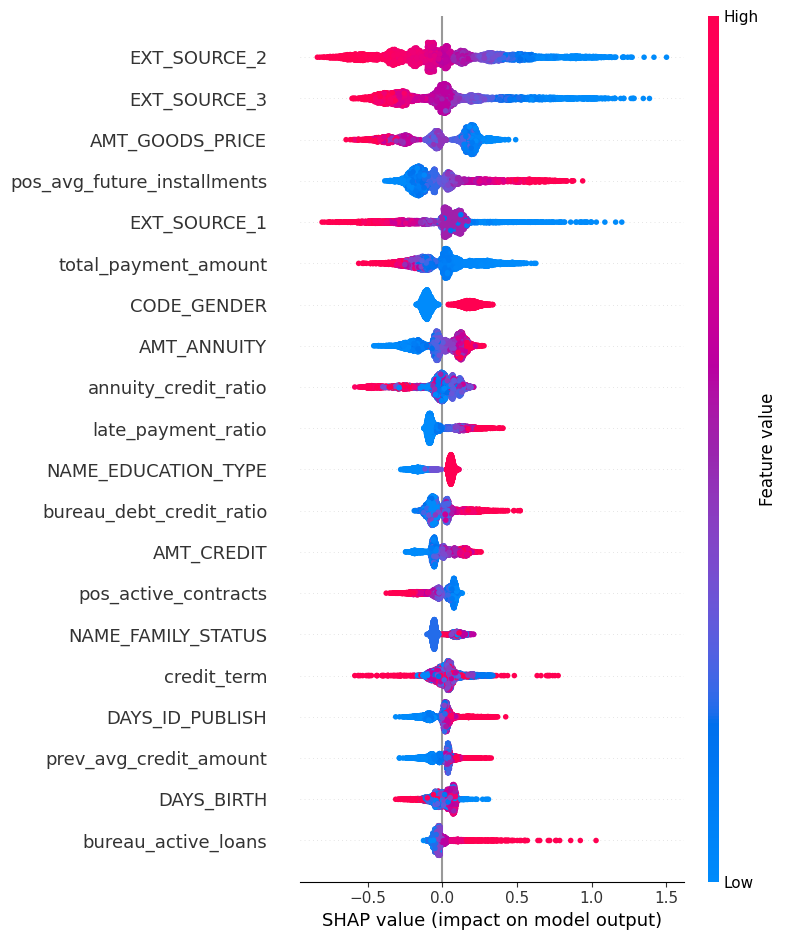

In [6]:
shap.summary_plot(
    shap_values,
    sample_X
)

### Üretilen Feature'lar SHAP Top 20'

| Feature                     | Kaynak                |
| --------------------------- | --------------------- |
| pos_avg_future_installments | POS Cash              |
| total_payment_amount        | Installments          |
| late_payment_ratio          | Installments          |
| avg_days_late               | Installments          |
| bureau_debt_credit_ratio    | Bureau                |
| credit_term                 | Application FE        |
| refusal_rate                | Previous Applications |
| cc_utilization_ratio        | Credit Card           |
| annuity_credit_ratio        | Application FE        |


In [2]:
import joblib
import shap
import pandas as pd
import matplotlib.pyplot as plt

from src.preprocessing.prepare_dataset import (
    prepare_dataset
)

In [3]:
df = prepare_dataset(
    "../data/processed/train_feature_store.parquet"
)

X = df.drop(columns=["TARGET"])

print(X.shape)

(307511, 217)


In [4]:
model = joblib.load(
    "../artifacts/models/lgbm_optuna_cv.pkl"
)

type(model)

lightgbm.sklearn.LGBMClassifier

In [5]:
explainer = shap.TreeExplainer(model)

sample = X.sample(
    2000,
    random_state=42
)

shap_values = explainer.shap_values(sample)

c:\Users\ASUS\creditguard-ai\venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [6]:
len(shap_values)

2000

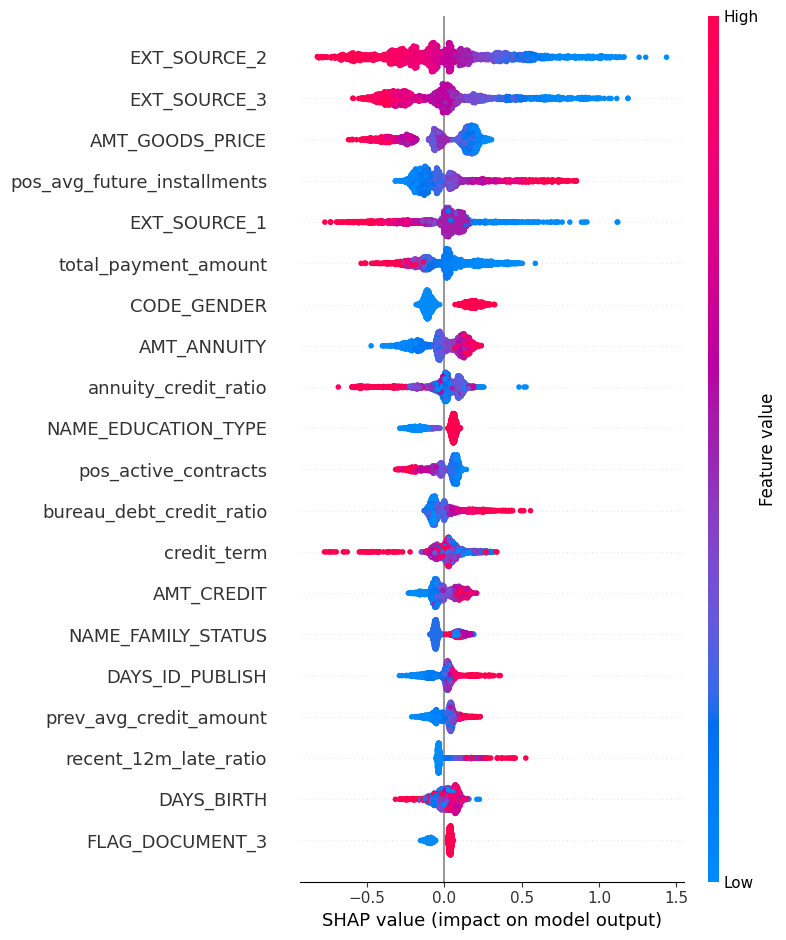

In [7]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    sample,
    max_display=20
)

In [8]:
import numpy as np

shap_importance = pd.DataFrame({
    "feature": sample.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
)

shap_importance.head(30)

,feature,mean_abs_shap
40,EXT_SOURCE_2,0.298285
41,EXT_SOURCE_3,0.249139
8,AMT_GOODS_PRICE,0.184160
176,pos_avg_future_installments,0.165693
39,EXT_SOURCE_1,0.152358
166,total_payment_amount,0.140978
1,CODE_GENDER,0.133864
7,AMT_ANNUITY,0.114567
130,annuity_credit_ratio,0.102356
11,NAME_EDUCATION_TYPE,0.090008
